<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/06_Matrices%2CPart_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 6: Matrix Spaces

**Referensi:** Practical Linear Algebra for Data Science (O'Reilly) - Mike X Cohen

---

## Ringkasan Bab

Bab ini membahas konsep **subspace** (ruang vektor) yang berkaitan dengan sebuah matriks. Ada empat subspace fundamental yang terkait dengan setiap matriks, yang dikenal sebagai **The Four Fundamental Subspaces** (empat ruang fundamental) dari Gilbert Strang.

Topik utama yang dibahas:
- Column space (range space) dari matriks
- Row space dari matriks
- Null space (kernel) dari matriks
- Left null space dari matriks
- Hubungan antara keempat subspace tersebut
- Ortogonalitas antara subspace
- Aplikasi dalam machine learning

## 6.1 Apa Itu Subspace?

**Subspace** adalah himpunan bagian dari ruang vektor yang memenuhi tiga syarat:
1. Mengandung vektor nol (0)
2. Tertutup terhadap penjumlahan: jika u dan v ada dalam subspace, maka u + v juga ada
3. Tertutup terhadap perkalian skalar: jika v ada dalam subspace dan c adalah skalar, maka cv juga ada

Setiap matriks m x n mendefinisikan empat subspace fundamental:
- **Column space C(A)**: ada dalam R^m
- **Row space C(A^T)**: ada dalam R^n  
- **Null space N(A)**: ada dalam R^n
- **Left null space N(A^T)**: ada dalam R^m

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## 6.2 Column Space (Ruang Kolom)

**Column space** dari matriks A, dinotasikan C(A) atau Col(A), adalah himpunan semua kombinasi linear dari kolom-kolom A. Secara formal:

```
C(A) = { Ax | x ada di R^n }
```

Column space menjawab pertanyaan: **vektor b mana yang bisa ditulis sebagai Ax?**

Sistem Ax = b memiliki solusi jika dan hanya jika b berada di dalam C(A).

Dimensi dari C(A) = rank(A).

In [2]:
# Demonstrasi column space
A = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [1, 1, 2]
], dtype=float)

print('Matrix A:')
print(A)
print()
print('Kolom-kolom A:')
print('c1 =', A[:, 0])
print('c2 =', A[:, 1])
print('c3 =', A[:, 2])
print()
print('Perhatikan: c3 = c1 + c2 (linearly dependent!)')
print('Sehingga rank(A) =', np.linalg.matrix_rank(A))

Matrix A:
[[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]

Kolom-kolom A:
c1 = [1. 0. 1.]
c2 = [0. 1. 1.]
c3 = [1. 1. 2.]

Perhatikan: c3 = c1 + c2 (linearly dependent!)
Sehingga rank(A) = 2


In [3]:
# Cek apakah vektor b ada di dalam column space A
# Caranya: cek apakah sistem Ax = b memiliki solusi

b_in = np.array([2, 3, 5])   # b = 2*c1 + 3*c2 = [2,3,5], harus ada di column space
b_out = np.array([1, 0, 0])  # cek apakah ini ada di column space

def is_in_column_space(A, b):
    """Cek apakah b ada di column space A dengan membandingkan rank."""
    Ab = np.column_stack([A, b])
    return np.linalg.matrix_rank(A) == np.linalg.matrix_rank(Ab)

print('b_in =', b_in)
print('Apakah b_in ada di C(A)?', is_in_column_space(A, b_in))
print()
print('b_out =', b_out)
print('Apakah b_out ada di C(A)?', is_in_column_space(A, b_out))

b_in = [2 3 5]
Apakah b_in ada di C(A)? True

b_out = [1 0 0]
Apakah b_out ada di C(A)? False


## 6.3 Row Space (Ruang Baris)

**Row space** dari matriks A, dinotasikan C(A^T) atau Row(A), adalah himpunan semua kombinasi linear dari baris-baris A. Ini sama dengan column space dari A^T.

Properti penting:
- Dimensi row space = rank(A)
- Dimensi row space = dimensi column space (keduanya sama dengan rank!)
- Row space ada di R^n (sama dengan null space)
- Row space dan null space **orthogonal complement** satu sama lain dalam R^n

In [4]:
# Demonstrasi row space
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=float)

print('Matrix A:')
print(A)
print()
print('Baris-baris A:')
print('r1 =', A[0, :])
print('r2 =', A[1, :])
print('r3 =', A[2, :])
print()
print('Rank(A) =', np.linalg.matrix_rank(A))
print('Rank(A^T) =', np.linalg.matrix_rank(A.T))
print('Dimensi row space = dimensi column space =', np.linalg.matrix_rank(A))

Matrix A:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

Baris-baris A:
r1 = [1. 2. 3.]
r2 = [4. 5. 6.]
r3 = [7. 8. 9.]

Rank(A) = 2
Rank(A^T) = 2
Dimensi row space = dimensi column space = 2


In [5]:
# Basis untuk row space menggunakan RREF
from sympy import Matrix

A_sym = Matrix([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print('Row space basis (non-zero rows of RREF):')
rref, pivots = A_sym.rref()
print(rref)
print('Pivot positions:', pivots)
print()

# Baris-baris non-nol dari RREF membentuk basis untuk row space
rref_np = np.array(rref.tolist(), dtype=float)
nonzero_rows = [rref_np[i] for i in range(rref_np.shape[0])
                if not np.allclose(rref_np[i], 0)]
print('Basis baris (dari RREF):')
for i, row in enumerate(nonzero_rows):
    print(f'  b{i+1} = {row}')

Row space basis (non-zero rows of RREF):
Matrix([[1, 0, -1], [0, 1, 2], [0, 0, 0]])
Pivot positions: (0, 1)

Basis baris (dari RREF):
  b1 = [ 1.  0. -1.]
  b2 = [0. 1. 2.]


## 6.4 Null Space (Ruang Nol / Kernel)

**Null space** dari matriks A, dinotasikan N(A) atau ker(A), adalah himpunan semua vektor x yang memenuhi:

```
Ax = 0
```

Null space selalu mengandung vektor nol. Jika A full column rank, maka null space hanya berisi vektor nol {0}.

Dimensi dari null space disebut **nullity**, dan berdasarkan teorema rank-nullity:
```
rank(A) + nullity(A) = n (jumlah kolom)
```

In [6]:
# Null space dari matriks rank-deficient
A = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=float)

# Hitung null space menggunakan SVD
# Kolom V dari SVD yang bersesuaian dengan singular value ~0 adalah null space
U, S, Vt = np.linalg.svd(A)

print('Singular values A:', np.round(S, 8))
print()

# Ambil kolom-kolom V yang bersesuaian dengan singular value yang sangat kecil
tol = 1e-10
null_mask = S < tol

# Rank A = 2, jadi nullity = 3 - 2 = 1, ada 1 vektor null
null_space = Vt[len(S):].T  # baris terakhir Vt (bila S menjadi nol)
# Cara lebih langsung:
null_vec = Vt[-1]  # singular value terkecil bersesuaian dengan baris terakhir Vt
print('Vektor null space:', np.round(null_vec, 6))

# Verifikasi: A @ null_vec harus mendekati 0
print('A @ null_vec (harus ~0):', np.round(A @ null_vec, 10))

Singular values A: [16.84810335  1.06836951  0.        ]

Vektor null space: [-0.408248  0.816497 -0.408248]
A @ null_vec (harus ~0): [0. 0. 0.]


In [7]:
# Menggunakan scipy untuk null space yang lebih lengkap
from scipy.linalg import null_space

A_test = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
], dtype=float)

ns = null_space(A_test)
print('A_test shape:', A_test.shape)
print('Rank:', np.linalg.matrix_rank(A_test))
print('Nullity = n - rank =', A_test.shape[1] - np.linalg.matrix_rank(A_test))
print()
print('Null space (basis vectors sebagai kolom):')
print(np.round(ns, 6))

# Verifikasi
print()
print('Verifikasi A @ null_space (harus ~0):')
print(np.round(A_test @ ns, 10))

A_test shape: (3, 4)
Rank: 2
Nullity = n - rank = 2

Null space (basis vectors sebagai kolom):
[[ 0.445272  0.318956]
 [-0.831432 -0.093389]
 [ 0.327048 -0.770091]
 [ 0.059112  0.544523]]

Verifikasi A @ null_space (harus ~0):
[[-0.  0.]
 [-0.  0.]
 [ 0.  0.]]


## 6.5 Left Null Space

**Left null space** dari A, dinotasikan N(A^T), adalah null space dari A^T. Ini adalah himpunan semua vektor y yang memenuhi:

```
A^T y = 0  (ekivalen dengan y^T A = 0)
```

Left null space ada di R^m dan merupakan orthogonal complement dari column space C(A) dalam R^m.

Dimensi left null space = m - rank(A)

In [8]:
# Left null space
A = np.array([
    [1, 2],
    [3, 6],
    [5, 10]
], dtype=float)

print('A shape:', A.shape, '(m=3, n=2)')
print('Rank(A):', np.linalg.matrix_rank(A))
print('Nullity(A^T) = m - rank(A) =', A.shape[0] - np.linalg.matrix_rank(A))

# Hitung left null space = null space dari A^T
left_ns = null_space(A.T)
print()
print('Left null space (basis vectors sebagai kolom):')
print(np.round(left_ns, 6))

# Verifikasi: A^T @ y harus = 0
print()
print('Verifikasi A^T @ left_ns (harus ~0):')
print(np.round(A.T @ left_ns, 10))

A shape: (3, 2) (m=3, n=2)
Rank(A): 1
Nullity(A^T) = m - rank(A) = 2

Left null space (basis vectors sebagai kolom):
[[-0.507093 -0.845154]
 [ 0.780038 -0.366604]
 [-0.366604  0.388993]]

Verifikasi A^T @ left_ns (harus ~0):
[[-0.  0.]
 [-0.  0.]]


## 6.6 Empat Subspace Fundamental: Ringkasan

Untuk matriks A berukuran m x n dengan rank r:

| Subspace | Notasi | Berada di | Dimensi |
|---|---|---|---|
| Column space | C(A) | R^m | r |
| Row space | C(A^T) | R^n | r |
| Null space | N(A) | R^n | n - r |
| Left null space | N(A^T) | R^m | m - r |

Hubungan ortogonalitas:
- C(A) perp N(A^T) dalam R^m
- C(A^T) perp N(A) dalam R^n

In [9]:
# Demonstrasi lengkap keempat subspace
np.random.seed(42)

# Buat matriks 4x3 dengan rank 2
A = np.random.randn(4, 2) @ np.random.randn(2, 3)
m, n = A.shape
r = np.linalg.matrix_rank(A)

print('=== Empat Subspace Fundamental ===')
print(f'Matriks A: {m} x {n}, rank = {r}')
print()
print(f'1. Column space C(A): dimensi {r}, berada di R^{m}')
print(f'2. Row space C(A^T): dimensi {r}, berada di R^{n}')
print(f'3. Null space N(A): dimensi {n-r}, berada di R^{n}')
print(f'4. Left null space N(A^T): dimensi {m-r}, berada di R^{m}')
print()
print(f'Cek total dimensi di R^{n}: row space + null space = {r} + {n-r} = {r+n-r} (harus = {n})')
print(f'Cek total dimensi di R^{m}: column space + left null space = {r} + {m-r} = {r+m-r} (harus = {m})')

=== Empat Subspace Fundamental ===
Matriks A: 4 x 3, rank = 2

1. Column space C(A): dimensi 2, berada di R^4
2. Row space C(A^T): dimensi 2, berada di R^3
3. Null space N(A): dimensi 1, berada di R^3
4. Left null space N(A^T): dimensi 2, berada di R^4

Cek total dimensi di R^3: row space + null space = 2 + 1 = 3 (harus = 3)
Cek total dimensi di R^4: column space + left null space = 2 + 2 = 4 (harus = 4)


## 6.7 Ortogonalitas antara Subspace

Salah satu hasil yang paling elegan dalam aljabar linear adalah bahwa pasangan-pasangan subspace di atas saling orthogonal:

1. **Row space perp Null space**: Setiap vektor di row space orthogonal dengan setiap vektor di null space
2. **Column space perp Left null space**: Setiap vektor di column space orthogonal dengan setiap vektor di left null space

Lebih dari itu, mereka adalah **orthogonal complements** satu sama lain, yang berarti bersama-sama mereka mencakup seluruh ruang.

In [10]:
# Demonstrasi ortogonalitas row space dan null space
np.random.seed(10)

A = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
], dtype=float)

# Hitung row space basis (baris-baris non-nol dari RREF)
A_sym = Matrix(A.astype(int))
rref, pivots = A_sym.rref()
rref_np = np.array(rref.tolist(), dtype=float)
row_basis = rref_np[:len(pivots)]  # ambil baris-baris yang memiliki pivot

# Hitung null space
ns = null_space(A)

print('Basis Row Space:')
for i, row in enumerate(row_basis):
    print(f'  r{i+1} = {np.round(row, 4)}')

print()
print('Basis Null Space:')
for i in range(ns.shape[1]):
    print(f'  n{i+1} = {np.round(ns[:, i], 4)}')

print()
print('Dot products (row basis vs null space basis) -- harus ~0:')
for i, row in enumerate(row_basis):
    for j in range(ns.shape[1]):
        dp = np.dot(row, ns[:, j])
        print(f'  r{i+1} . n{j+1} = {np.round(dp, 10)}')

Basis Row Space:
  r1 = [ 1.  0. -1. -2.]
  r2 = [0. 1. 2. 3.]

Basis Null Space:
  n1 = [ 0.4453 -0.8314  0.327   0.0591]
  n2 = [ 0.319  -0.0934 -0.7701  0.5445]

Dot products (row basis vs null space basis) -- harus ~0:
  r1 . n1 = 0.0
  r1 . n2 = 0.0
  r2 . n1 = -0.0
  r2 . n2 = -0.0


In [11]:
# Demonstrasi ortogonalitas column space dan left null space
from scipy.linalg import orth

# Basis column space (kolom-kolom yang sesuai dengan pivot)
col_basis = orth(A.T).T  # baris-baris orthonormal dari row space
col_basis_A = orth(A)    # basis column space dari A

# Left null space
left_ns = null_space(A.T)

print('Basis Column Space (A):')
print(np.round(col_basis_A, 4))

print()
print('Left Null Space basis:')
print(np.round(left_ns, 4))

print()
print('Dot product column space vs left null space (harus ~0):')
print(np.round(col_basis_A.T @ left_ns, 10))

Basis Column Space (A):
[[ 0.2067  0.8892]
 [ 0.5183  0.2544]
 [ 0.8298 -0.3804]]

Left Null Space basis:
[[-0.4082]
 [ 0.8165]
 [-0.4082]]

Dot product column space vs left null space (harus ~0):
[[-0.]
 [-0.]]


## 6.8 Proyeksi ke Subspace

**Proyeksi** adalah operasi yang sangat penting terkait subspace. Proyeksi vektor b ke column space dari A diberikan oleh:

```
p = A(A^T A)^{-1} A^T b
```

Matriks **P = A(A^T A)^{-1} A^T** disebut **projection matrix** atau **hat matrix**. Sifat-sifat:
- P^2 = P (idempoten)
- P^T = P (simetris)
- Eigenvalue P hanya 0 atau 1
- Trace(P) = rank(A)

In [12]:
# Projection matrix
A = np.array([
    [1, 0],
    [0, 1],
    [0, 0]
], dtype=float)

# P = A (A^T A)^{-1} A^T
P = A @ np.linalg.inv(A.T @ A) @ A.T

print('Matrix A (3x2):')
print(A)
print()
print('Projection matrix P (3x3):')
print(np.round(P, 4))

print()
print('Cek sifat idempoten (P^2 = P)?', np.allclose(P @ P, P))
print('Cek sifat simetris (P^T = P)?', np.allclose(P.T, P))
print('Trace(P) = rank(A)?', np.round(np.trace(P), 6), '==', np.linalg.matrix_rank(A))

Matrix A (3x2):
[[1. 0.]
 [0. 1.]
 [0. 0.]]

Projection matrix P (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]

Cek sifat idempoten (P^2 = P)? True
Cek sifat simetris (P^T = P)? True
Trace(P) = rank(A)? 2.0 == 2


In [13]:
# Proyeksi vektor ke column space
b = np.array([1, 2, 3], dtype=float)  # vektor di R^3 yang tidak ada di column space A

p = P @ b  # proyeksi b ke column space A
e = b - p  # error: komponen b yang orthogonal terhadap column space A

print('Vektor b (original):', b)
print('Proyeksi p = Pb:', np.round(p, 4))
print('Error e = b - p:', np.round(e, 4))

print()
print('Cek: p ada di column space A (Ax = p punya solusi)?')
print('Rank([A|p]) == Rank(A)?',
      np.linalg.matrix_rank(np.column_stack([A, p])) == np.linalg.matrix_rank(A))

print()
print('Cek: e orthogonal terhadap column space A (e perp setiap kolom A)?')
print('A^T e (harus ~0):', np.round(A.T @ e, 10))

Vektor b (original): [1. 2. 3.]
Proyeksi p = Pb: [1. 2. 0.]
Error e = b - p: [0. 0. 3.]

Cek: p ada di column space A (Ax = p punya solusi)?
Rank([A|p]) == Rank(A)? True

Cek: e orthogonal terhadap column space A (e perp setiap kolom A)?
A^T e (harus ~0): [0. 0.]


## 6.9 Aplikasi: Least Squares dan Proyeksi

Hubungan antara proyeksi dan **least squares** sangat erat. Ketika sistem Ax = b tidak memiliki solusi (karena b tidak berada di column space A), kita mencari solusi terbaik yang meminimalkan ||Ax - b||^2.

Solusi least squares adalah:
```
x_hat = (A^T A)^{-1} A^T b
```

Dan prediksinya adalah:
```
b_hat = A x_hat = A(A^T A)^{-1} A^T b = Pb
```

Jadi solusi least squares adalah proyeksi b ke column space A!

Koefisien least squares [intercept, slope]: [1.4232 1.8235]

Cek residual orthogonal terhadap column space:
A^T @ residual (harus ~0): [-0. -0.]


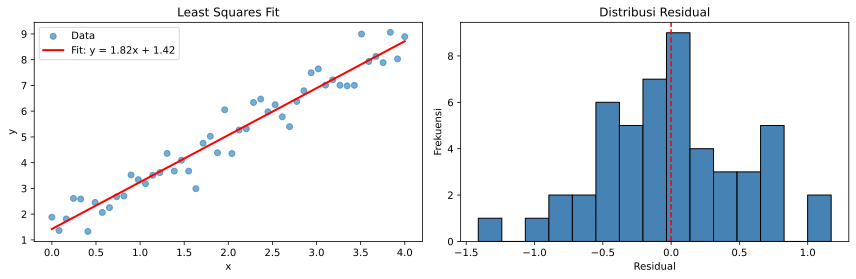

In [14]:
# Demonstrasi least squares sebagai proyeksi
np.random.seed(0)

# Generate data regresi sederhana
n = 50
x = np.linspace(0, 4, n)
y = 2 * x + 1 + np.random.randn(n) * 0.5  # y = 2x + 1 + noise

# Buat matriks desain A
A = np.column_stack([np.ones(n), x])

# Least squares solution: x_hat = (A^T A)^{-1} A^T y
x_hat = np.linalg.inv(A.T @ A) @ A.T @ y

# Prediksi (proyeksi y ke column space A)
y_hat = A @ x_hat

# Residual
residual = y - y_hat

print('Koefisien least squares [intercept, slope]:', np.round(x_hat, 4))
print()
print('Cek residual orthogonal terhadap column space:')
print('A^T @ residual (harus ~0):', np.round(A.T @ residual, 8))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x, y, alpha=0.6, label='Data')
axes[0].plot(x, y_hat, 'r-', linewidth=2, label=f'Fit: y = {x_hat[1]:.2f}x + {x_hat[0]:.2f}')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Least Squares Fit')
axes[0].legend()

axes[1].hist(residual, bins=15, edgecolor='black', color='steelblue')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

## 6.10 Dekomposisi Ax = b Menggunakan Subspace

Pemahaman tentang subspace membantu kita menganalisis solusi sistem linear Ax = b:

**Kasus 1: b ada di C(A)**
- Sistem memiliki setidaknya satu solusi
- Jika A full column rank: solusi unik
- Jika A rank-deficient: tak hingga banyak solusi (differ by null space vectors)

**Kasus 2: b tidak ada di C(A)**
- Sistem tidak memiliki solusi eksak
- Gunakan least squares untuk solusi terbaik

In [15]:
# Demonstrasi solusi ketika A tidak full column rank
A = np.array([
    [1, 2, 3],
    [0, 1, 1],
    [1, 3, 4]
], dtype=float)

# Kolom ketiga = kolom pertama + kolom kedua
b = np.array([6, 2, 8], dtype=float)  # b ada di column space

print('Rank(A):', np.linalg.matrix_rank(A))
print('A tidak full column rank -> ada tak hingga solusi')
print()

# Satu solusi khusus: gunakan least squares (minimum norm)
x_special, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
print('Solusi minimum norm:', np.round(x_special, 4))
print('Verifikasi A @ x_special = b?', np.allclose(A @ x_special, b))

# Null space
ns = null_space(A)
print()
print('Null space basis:', np.round(ns.flatten(), 4))

# Solusi lain: tambahkan vektor null space
x_other = x_special + 2 * ns.flatten()
print()
print('Solusi lain (x_special + 2*null_vec):', np.round(x_other, 4))
print('Verifikasi A @ x_other = b?', np.allclose(A @ x_other, b))

Rank(A): 2
A tidak full column rank -> ada tak hingga solusi

Solusi minimum norm: [0.6667 0.6667 1.3333]
Verifikasi A @ x_special = b? True

Null space basis: [-0.5774 -0.5774  0.5774]

Solusi lain (x_special + 2*null_vec): [-0.488 -0.488  2.488]
Verifikasi A @ x_other = b? True


## 6.11 Visualisasi Subspace dalam 2D

Untuk matriks 2x2, kita bisa memvisualisasikan subspace secara geometris. Column space dan null space membentuk garis-garis (atau titik asal) dalam R^2.

Matrix A:
[[1. 2.]
 [2. 4.]]
Rank: 1
Arah column space: [0.4472 0.8944]
Arah null space: [-0.8944  0.4472]
Dot product (harus ~0): 0.0


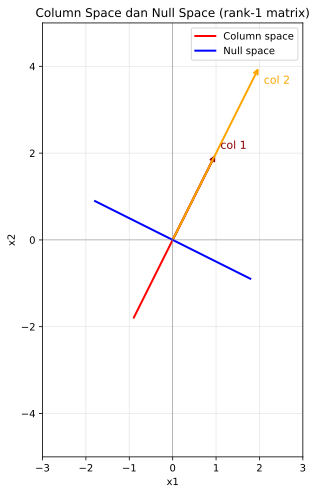

In [16]:
# Visualisasi column space dan null space untuk matriks 2x2 rank-1
A = np.array([[1, 2], [2, 4]], dtype=float)  # kolom 2 = 2 * kolom 1

print('Matrix A:')
print(A)
print('Rank:', np.linalg.matrix_rank(A))

# Column space: span dari [1, 2] (satu dimensi dalam R^2)
col_dir = A[:, 0] / np.linalg.norm(A[:, 0])

# Null space: vektor x sehingga Ax = 0
ns = null_space(A)
null_dir = ns[:, 0] / np.linalg.norm(ns[:, 0])

print('Arah column space:', np.round(col_dir, 4))
print('Arah null space:', np.round(null_dir, 4))
print('Dot product (harus ~0):', np.round(np.dot(col_dir, null_dir), 10))

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

t = np.linspace(-2, 2, 100)

# Column space (garis merah)
ax.plot(t * col_dir[0], t * col_dir[1], 'r-', linewidth=2, label='Column space')

# Null space (garis biru)
ax.plot(t * null_dir[0], t * null_dir[1], 'b-', linewidth=2, label='Null space')

# Kolom-kolom A
ax.annotate('', xy=A[:, 0], xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2))
ax.annotate('', xy=A[:, 1], xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2))

ax.text(A[0, 0]*1.1, A[1, 0]*1.05, 'col 1', fontsize=11, color='darkred')
ax.text(A[0, 1]*1.05, A[1, 1]*0.9, 'col 2', fontsize=11, color='orange')

ax.set_xlim(-3, 3)
ax.set_ylim(-5, 5)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Column Space dan Null Space (rank-1 matrix)')
ax.legend()
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6.12 Aplikasi dalam Machine Learning: PCA dan Subspace

**Principal Component Analysis (PCA)** dapat dipahami melalui konsep subspace:
- PCA mencari **subspace berdimensi rendah** yang menangkap variansi terbesar dari data
- Komponen-komponen principal adalah arah-arah dalam **column space** dari matriks kovarians
- Variansi yang "dibuang" (komponen minor) bersesuaian dengan arah-arah yang mendekati null space

Low-rank matrix approximation memproyeksikan data ke subspace berdimensi k.

Matriks kovarians:
[[1.0582 0.7871]
 [0.7871 0.7174]]

Eigenvalues (variansi tiap PC): [1.6931 0.0825]
PC1 direction: [-0.7783 -0.6279]
PC2 direction: [ 0.6279 -0.7783]

Ortogonal? 0.0


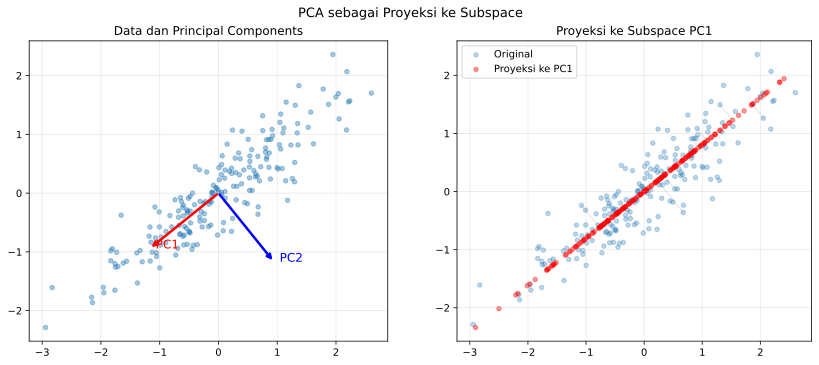

In [17]:
# Demonstrasi sederhana PCA sebagai proyeksi subspace
np.random.seed(5)

# Data 2D dengan korelasi kuat
n = 200
t = np.random.randn(n)
X = np.column_stack([t + 0.3 * np.random.randn(n),
                     0.8 * t + 0.3 * np.random.randn(n)])

# Centralisasi data
X_c = X - X.mean(axis=0)

# Matriks kovarians
C = X_c.T @ X_c / (n - 1)
print('Matriks kovarians:')
print(np.round(C, 4))

# Eigendecomposition
eigenvals, eigenvecs = np.linalg.eigh(C)
idx = np.argsort(eigenvals)[::-1]  # urutkan dari terbesar
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:, idx]

print()
print('Eigenvalues (variansi tiap PC):', np.round(eigenvals, 4))
print('PC1 direction:', np.round(eigenvecs[:, 0], 4))
print('PC2 direction:', np.round(eigenvecs[:, 1], 4))
print()
print('Ortogonal?', np.round(eigenvecs[:, 0] @ eigenvecs[:, 1], 10))

# Proyeksi ke PC1 (1D subspace)
X_proj = X_c @ eigenvecs[:, :1] @ eigenvecs[:, :1].T

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_c[:, 0], X_c[:, 1], alpha=0.4, s=20, label='Data')
scale = 1.5
axes[0].annotate('', xy=scale*eigenvecs[:, 0], xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
axes[0].annotate('', xy=scale*eigenvecs[:, 1], xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
axes[0].text(scale*eigenvecs[0, 0]+0.1, scale*eigenvecs[1, 0], 'PC1', color='red', fontsize=12)
axes[0].text(scale*eigenvecs[0, 1]+0.1, scale*eigenvecs[1, 1], 'PC2', color='blue', fontsize=12)
axes[0].set_title('Data dan Principal Components')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_c[:, 0], X_c[:, 1], alpha=0.3, s=20, label='Original')
axes[1].scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.4, s=20, color='red', label='Proyeksi ke PC1')
for i in range(0, n, 10):
    axes[1].plot([X_c[i, 0], X_proj[i, 0]], [X_c[i, 1], X_proj[i, 1]],
                 'k-', alpha=0.2, linewidth=0.5)
axes[1].set_title('Proyeksi ke Subspace PC1')
axes[1].set_aspect('equal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA sebagai Proyeksi ke Subspace', fontsize=13)
plt.tight_layout()
plt.show()

## Ringkasan Bab 6

Pada bab ini kita telah mempelajari:

1. **Subspace** adalah himpunan yang tertutup terhadap penjumlahan dan perkalian skalar, serta mengandung vektor nol.

2. **Empat Subspace Fundamental** dari matriks A berukuran m x n:
   - Column space C(A): dimensi r, di R^m
   - Row space C(A^T): dimensi r, di R^n
   - Null space N(A): dimensi n-r, di R^n
   - Left null space N(A^T): dimensi m-r, di R^m

3. **Ortogonalitas**: Row space perp null space, column space perp left null space.

4. **Projection matrix** P = A(A^T A)^{-1} A^T memproyeksikan vektor sembarang ke column space A.

5. **Least squares** adalah proyeksi b ke column space A, memberikan solusi Ax = b yang terbaik saat b tidak berada di C(A).

6. Konsep subspace mendasari banyak algoritma ML seperti **PCA** dan **matrix factorization**.